### Instruction by instruction

## Imports

In [114]:
from typing import Any

from kirin.ir import Method
import matplotlib.pyplot as plt
import numpy as np

from bloqade import squin, tsim
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList
import matplotlib.pyplot as plt

# this will help us have return types for our methods that have more intuitive names
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

## Team Synthesis

#### Team Synthesis Part 1: Learn the language of Clifford+ $T$

##### Team Synthesis Part 1a: Hadamard (single-qubit gate)

In [2]:
@squin.kernel
def h_state() -> Measurement:
    qubits = squin.qalloc(1)
    squin.h(qubits[0])
    bits = squin.broadcast.measure(qubits)
    return bits

In [3]:
pyqrack_target = StackMemorySimulator(min_qubits=1)
task = pyqrack_target.task(h_state)
batch_results = task.batch_run(shots=1000)
print(batch_results)
show_circuit(h_state)

{(<Measurement.One: 1>,): 0.508, (<Measurement.Zero: 0>,): 0.492}


##### Team Synthesis Part 1b: CNOT (2-qubit gate)

In [4]:
@squin.kernel
def cnot_no_op() -> Measurement:
    qubits = squin.qalloc(2)
    squin.cx(qubits[0],qubits[1])
    bits = squin.broadcast.measure(qubits)
    return bits

In [5]:
pyqrack_target = StackMemorySimulator(min_qubits=2)
task = pyqrack_target.task(cnot_no_op)
batch_results = task.batch_run(shots=1000)
print(batch_results)
show_circuit(cnot_no_op)

{(<Measurement.Zero: 0>, <Measurement.Zero: 0>): 1.0}


In [6]:
@squin.kernel
def cnot_cntrl_on() -> Measurement:
    qubits = squin.qalloc(2)
    squin.x(qubits[0])
    squin.cx(qubits[0],qubits[1])
    bits = squin.broadcast.measure(qubits)
    return bits

In [7]:
pyqrack_target = StackMemorySimulator(min_qubits=2)
task = pyqrack_target.task(cnot_cntrl_on)
batch_results = task.batch_run(shots=1000)
print(batch_results)
show_circuit(cnot_no_op)

{(<Measurement.One: 1>, <Measurement.One: 1>): 1.0}


#### Team Synthesis Part 2: Synthesize the rotation family

##### For this part, I'm thinking of looking at the actual matrices for the independent rotations and seeing if I can form a complex rotation as a result of mulitple rotations on top of eachother...?

$$
R_z(\pi/2^n), \qquad n \in \{0,1,2,3,4,5\}.
$$

##### In general, an Rz gate is described as such


$$
R_z(\theta) = 
\begin{pmatrix} 
e^{-i\theta/2} & 0 \\ 
0 & e^{i\theta/2} 
\end{pmatrix}
$$


Clifford + T gates include the following: $H, S, T,$ and $CNOT$



### Hadamard & Phase (S)
$$
H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \quad 
S = \begin{pmatrix} 1 & 0 \\ 0 & i \end{pmatrix}
$$

### CNOT (CX)
$$
CX = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}
$$

### T-Gate (Non-Clifford)
$$
T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & \frac{1+i}{\sqrt{2}} \end{pmatrix}
$$

#### We can make a kernel that does Rz and test a bunch of states?

In [8]:
@squin.kernel
def rotational_z(theta) -> Measurement:
    qubits = squin.qalloc(1)
    squin.x(qubits[0])
    squin.rz(theta, qubits[0])
    bits = squin.broadcast.measure(qubits)
    return bits

In [9]:
pyqrack_target = StackMemorySimulator(min_qubits=1)
theta = np.pi/10
task = pyqrack_target.task(rotational_z, (theta,))
batch_results = task.batch_run(shots=1000)
print(batch_results)
# show_circuit(lambda: rotational_z(theta))


{(<Measurement.One: 1>,): 1.0}


#### 180 degree rotation (n=0)

$$
R_z(\pi) = 
\begin{pmatrix} 
e^{-i\pi/2} & 0 \\ 
0 & e^{i\pi/2} 
\end{pmatrix}
$$

Using Euler's formula
$$
e^{j\theta} = \cos(\theta) + j\sin(\theta) \\
e^{i\pi/2} = \cos(\pi/2) + i\sin(\pi/2) \\
= +i
$$
Same for $e^{-i\pi/2}$ except the value is -i, we get a final matrix of 
$$
R_z(\pi) = 
\begin{pmatrix} 
1 & 0 \\ 
0 & -1 
\end{pmatrix}
$$
That is the Z-matrix. That's not in our Clifford + T, but, since I did this second (after 90 degrees) we can just apply 2 $S$ matrices and call it a day. 

#### 90 degree rotation (n=1)


$$
R_z(\pi/2) = 
\begin{pmatrix} 
e^{-i\pi/4} & 0 \\ 
0 & e^{i\pi/4} 
\end{pmatrix}
$$


Using Euler's formula
$$
e^{j\theta} = \cos(\theta) + j\sin(\theta) \\
e^{i\pi/4} = \cos(\pi/4) + i\sin(\pi/4) \\
= \sqrt2 /2 + i \sqrt2 / 2
$$

$e^{-j\theta}$ is the same just with a $-i\sin$, 

plug that into the matrix, factor out the sqrt2/2 and the (1-i), simplify


$$
R_z(\pi/2) = 
\begin{pmatrix} 
1 & 0 \\ 
0 & i 
\end{pmatrix}
$$
Which is the $S$ matrix!

#### 45 degree rotation (n=2)

Start with the definition
$$
R_z(\pi/4) = 
\begin{pmatrix} 
e^{-i\pi/8} & 0 \\ 
0 & e^{i\pi/8} 
\end{pmatrix}
$$
Factor out a $e^{-i\pi/8}$

$$
R_z(\pi/4) = 
\begin{pmatrix} 
1 & 0 \\ 
0 & e^{i\pi/8} / e^{-i\pi/8} 
\end{pmatrix}
$$
Simplify
$$
R_z(\pi/4) = 
\begin{pmatrix} 
1 & 0 \\ 
0 & e^{2i\pi/8} 
\end{pmatrix}
$$
Final push
$$
R_z(\pi/4) = 
\begin{pmatrix} 
1 & 0 \\ 
0 & e^{i\pi/4}
\end{pmatrix}
$$
And that's the $T$ matrix!

#### 22.5 degree rotation (n=3)

$$
R_z(\pi/8) = 
\begin{pmatrix} 
e^{-i\pi/16} & 0 \\ 
0 & e^{i\pi/16} 
\end{pmatrix}
$$

After factoring and all cool things, 
$$
R_z(\pi/8) = 
\begin{pmatrix} 
1 & 0 \\ 
0 & e^{i\pi/8} 
\end{pmatrix}
$$
This doesn't really resemble...anything? As in, this is not EXACTLY described by any of the matrices in Clifford + $T$, so we have to approximate!

IF we're approximating, let's consider the set that we have. Clifford + $T$ is $H,S,T$ and $CNOT$. Looking at some visualizers, our team tried to understand how to approach this 22.5 degree rotation. We noticed in visual tools that the Hadamard, S, T matrix interleaved was getting...closer to the right answer...

After the initial visualization and some matrix calculations by hand on a whiteboard, we realized that we might want to reconsider what we're doing. We wanted to make an algorithm to try and run different combinations of matrices.

Initially, we thought of doing a "gradient descent" like problem solution, where we would pick the best gate in the set that would drop the distance as much as possible, in a "greedy algorithm" manner. Then, we considered the possibiltiy that a locally-unoptimal gate might lead to better solutions later, so we decided to implement a "future looking" to the algorithm. Since the gate set is small enough, we can afford to look ahead by a step. Finally, we decided that we can make a hyperparameter titled "future" which would decide just how far you could go with your prediction.

Before we went and designed this, however, we had to consider a special constraint for this problem. From the challenge, we know that Non-Clifford gates are expensive, so we wanted to consider that when designed an algorithm that would pick the best quantum gate adaptively and try to prioritize the *other* gates instead. 

In [5]:
from itertools import product as iter_product

#using the formula given
def distance(A, B):
    A_conj_tp = A.conj().T
    val = np.abs(np.trace(A_conj_tp @ B)) / 2
    val = min(val, 1.0)
    return np.sqrt(1 - val)


In [2]:
def rz_matrix(theta):
    return np.array([
        [np.exp(-1j * theta / 2), 0],
        [0, np.exp(1j * theta / 2)]
    ], dtype=complex)

In [100]:
import numpy as np


H = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]], dtype=complex)
S = np.array([[1, 0], [0, 1j]], dtype=complex)
T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)
T_adj = T.conj().T
S_adj = S.conj().T

gate_set = {
    "H": H,
    "S": S,
    "T": T,
    "T†": T_adj,
    "S†": S_adj,
    "HT": H@T,
    "THST": T@H@S@T
}

def greedy_synthesis(target_matrix, tolerance=1e-6, max_depth=60, t_penalty=0.02):
    current = np.eye(2, dtype=complex)
    sequence = []
    skip = {('S','S†'),('S†','S'),('T','T†'),('T†','T'),('H','H')}

    for _ in range(max_depth):
        if distance(target_matrix, current) < tolerance:
            break
        best_score = float('inf')
        best_gate = None
        for name, mat in gate_set.items():
            if sequence and (sequence[-1], name) in skip:
                continue
            d = distance(target_matrix, mat @ current)
            score = d + (t_penalty if 'T' in name else 0)
            if score < best_score:
                best_score = score
                best_gate = name
        sequence.append(best_gate)
        current = gate_set[best_gate] @ current

    return sequence, current







In [103]:
for n in range(6):
    target = rz_matrix(np.pi / (2**n))
    
    if n >= 3:
        # Kick off with H -> T manually, then greedy from there
        current = gate_set['T'] @ gate_set['H']
        sequence = ['H', 'T']
        skip = {('S','S†'),('S†','S'),('T','T†'),('T†','T'),('H','H'),('T,T')}
        for _ in range(100):
            if distance(target, current) < 1e-12:
                break
            best_dist = float('inf')
            best_gate = None
            for name, mat in gate_set.items():
                if sequence and (sequence[-1], name) in skip:
                    continue
                d = distance(target, mat @ current)
                if d < best_dist:
                    best_dist = d
                    best_gate = name
            sequence.append(best_gate)
            current = gate_set[best_gate] @ current
        seq, mat = sequence, current
    else:
        seq, mat = greedy_synthesis(target, max_depth=60)
    
    dist = distance(target, mat)
    t_count = sum(1 for g in seq if 'T' in g)
    print(f"R_z(π/2^{n}):  {' -> '.join(seq)}")
    print(f"  Depth: {len(seq)} | T-count: {t_count} | Distance: {dist:.4e}\n")


R_z(π/2^0):  S -> S
  Depth: 2 | T-count: 0 | Distance: 0.0000e+00

R_z(π/2^1):  S
  Depth: 1 | T-count: 0 | Distance: 0.0000e+00

R_z(π/2^2):  T
  Depth: 1 | T-count: 1 | Distance: 0.0000e+00

R_z(π/2^3):  H -> T -> H -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S†
  Depth: 102 | T-count: 67 | Distance: 3.0639e-01

R_z(π/2^4):  H -> T -> H -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -> T -> S† -> T -

In [109]:
def beam_search(target_matrix, max_depth=20, beam_width=200):
    skip = {('S','S†'),('S†','S'),('T','T†'),('T†','T'),('H','H')}
    
    beam = [(np.eye(2, dtype=complex), [])]
    best_seq, best_mat, best_dist = [], np.eye(2, dtype=complex), float('inf')
    dist_history = []  # track best distance at each depth

    for depth in range(max_depth):
        candidates = []

        for current, sequence in beam:
            for name, mat in gate_set.items():
                if sequence and (sequence[-1], name) in skip:
                    continue
                new_mat = mat @ current
                new_seq = sequence + [name]
                d = distance(target_matrix, new_mat)

                if d < best_dist:
                    best_dist = d
                    best_mat = new_mat
                    best_seq = list(new_seq)

                candidates.append((d, new_mat, new_seq))

        candidates.sort(key=lambda x: x[0])
        beam = [(m, s) for _, m, s in candidates[:beam_width]]
        
        dist_history.append(best_dist)
        print(f"  depth {depth+1:2d} | best: {best_dist:.6e}")

        if best_dist < 1e-6:
            break

    return best_seq, best_mat, dist_history


R_z(π/2^0):
  RESULT: S -> S
  Depth: 2 | T-count: 0 | Distance: 0.0000e+00


R_z(π/2^1):
  RESULT: S
  Depth: 1 | T-count: 0 | Distance: 0.0000e+00


R_z(π/2^2):
  RESULT: T
  Depth: 1 | T-count: 1 | Distance: 0.0000e+00


R_z(π/2^3):
  depth  1 | best: 1.386172e-01
  depth  2 | best: 1.386172e-01
  depth  3 | best: 1.386172e-01
  depth  4 | best: 1.386172e-01
  depth  5 | best: 1.386172e-01
  depth  6 | best: 1.386172e-01
  depth  7 | best: 1.386172e-01
  depth  8 | best: 1.386172e-01
  depth  9 | best: 1.386172e-01
  depth 10 | best: 1.386172e-01
  depth 11 | best: 1.386172e-01
  depth 12 | best: 1.386172e-01
  depth 13 | best: 1.386172e-01
  depth 14 | best: 1.386172e-01
  depth 15 | best: 1.386172e-01
  depth 16 | best: 1.386172e-01
  depth 17 | best: 1.386172e-01
  depth 18 | best: 1.386172e-01
  depth 19 | best: 1.386172e-01
  depth 20 | best: 1.386172e-01
  RESULT: T
  Depth: 1 | T-count: 1 | Distance: 1.3862e-01


R_z(π/2^4):
  depth  1 | best: 2.075082e-01
  depth  2 | best: 

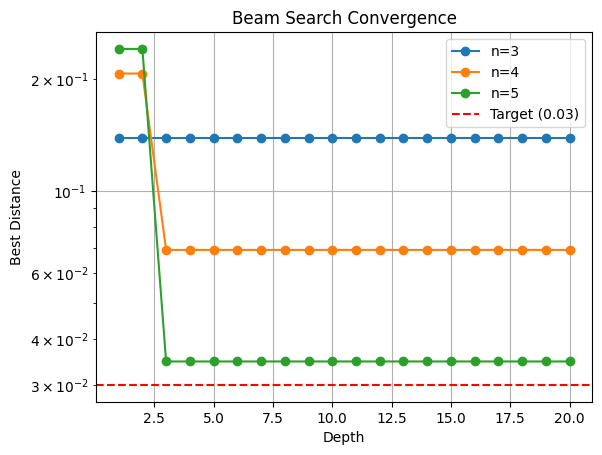

In [110]:
import matplotlib.pyplot as plt

all_histories = {}

for n in range(6):
    target = rz_matrix(np.pi / (2**n))
    print(f"R_z(π/2^{n}):")

    if n < 3:
        seq, mat = greedy_synthesis(target, max_depth=60)
        dist = distance(target, mat)
        t_count = sum(1 for g in seq if 'T' in g)
        print(f"  RESULT: {' -> '.join(seq)}")
        print(f"  Depth: {len(seq)} | T-count: {t_count} | Distance: {dist:.4e}\n")
    else:
        seq, mat, history = beam_search(target, max_depth=20, beam_width=200)
        all_histories[n] = history
        dist = distance(target, mat)
        t_count = sum(1 for g in seq if 'T' in g)
        print(f"  RESULT: {' -> '.join(seq)}")
        print(f"  Depth: {len(seq)} | T-count: {t_count} | Distance: {dist:.4e}\n")
    print("=" * 70 + "\n")

# Plot convergence
for n, history in all_histories.items():
    plt.plot(range(1, len(history)+1), history, marker='o', label=f'n={n}')

plt.xlabel('Depth')
plt.ylabel('Best Distance')
plt.title('Beam Search Convergence')
plt.axhline(y=0.03, color='r', linestyle='--', label='Target (0.03)')
plt.legend()
plt.yscale('log')
plt.grid(True)
plt.show()


#### In examples/astar_clifford, we implemented an A-star searching algorithm that continued beyond the greedy and beam search. It's performance was great, and so we shifted to using that!

## Team Synthesis Part 3: Non-Clifford gates are expensive


#### How do we get around not using T? The sequence we generated from the A* algorithm has T in it, but we're not allowed.


$$
T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix} = \begin{pmatrix} 1 & 0 \\ 0 & \frac{1+i}{\sqrt{2}} \end{pmatrix}
$$

Now, we extend and also add a restriction onto our system. We now have two qubits, have access to CNOT, but we CANNOT use T on the main qubit. So, we need to use quantum teleportation of a state onto the qubit. 

Here's the setup:

Imagine your main is in some state
$$
\ket\psi = \alpha\ket 0 + \beta \ket 1
$$

And your ancilla qubit is in $\ket0$.

Now, if you *were* able to apply the T-gate onto your state $\ket\psi$, you'd get the state $\alpha\ket0 + e^{i\pi/4}\beta\ket1$. Notably, the problem restricts this. How do we get around it?

To the ancilla bit, starting from $\ket0$, apply $H$ then $T$ to put the state into the $1/\sqrt2 (\ket0 + \beta e^{i\pi/4}\ket1)$. From here, apply the $CNOT$ gate, where the *main* qubit is the control, and the *ancilla* is the target. This forms the following state: 

$\ket\psi \otimes \ket T = 1/\sqrt2 (\alpha\ket0\ket0 + \alpha e^{i\pi/4}\ket0\ket1 + \beta\ket1\ket0 + \beta e^{i\pi/4}\ket1\ket1)$.

But wait, there is one piece of information missing. 

$T$ is not a high-fidelity gate. 
$T$ requires a conecpt called "15-1 distillation", where the following happens. 15 physical qubits (in $\ket0$) have the $H$ applied to all of them (i.e they're now all in $\ket+$). Then, the noisy $T$ gate is applied to all of them. Then, they're entangled with a mesh of CNOTs based on the [15,1,3] Reed-Muller code, in which 1 physical qubit is set as the surivor/clean node, and the rest are "used as checks". Due to this high connectivity, any little error will result in the error propagating throughout and all 15 qubits being unusable to make a clean $T$. This is the dominant cost of having $T$ gates, and this issue occurs with each time we setup the $\ket T$ state, i.e $T\ket+$


From here, do a Z-basis measurement, which will return a bit $m$. 

If $m = 0$, then the $T$ gate has been applied, no worries. \
If $m = 1$, however, then $T\dagger$ has been applied, meaning that we need to apply a $S$ gate to reset, then *rebuild* the whole circuit we just used again. 

How do I know it's been applied?

Well, if we go from the CNOT state that I had placed above, $1/\sqrt2 (\alpha\ket0\ket0 + \alpha e^{i\pi/4}\ket0\ket1 + \beta\ket1\ket0 + \beta e^{i\pi/4}\ket1\ket1)$, if $m$, the second value, is 0, then you keep the $\alpha\ket0 + \beta e^{i\pi/4} \ket1$, as those are the two that had the second qubit as 0. This forms $\alpha \ket0 + \beta e^{i\pi/4} \ket1$, which is equivalent to applying $T$ onto the original $\ket \psi$. If the measurement result was $m=1$, we'd need to take the states where the second qubit is 1, meaning $\alpha e^{i\pi/4} \ket0 + \beta \ket 1$, which is equivalent to applying $T^ \dagger$ onto the original $\ket \psi$


This, therefore, incurs a cost onto the sequences we form from the previous section (that we got from A*). For every T, we need to apply a Hadamard, a T gate, a CNOT, and a feed forward. Moreovoer, the measurement bit that decides application $m$ will be $m=1$, i.e not correct and requiring one extra $S$ gate to go back to $T$ ($S T^\dagger$ = $T$) (on top of rebuilding the previous), 50% of the time! This means the extra $S$ gates will accumulate with each $T$ gate. 




## Team Synthesis Part 4: Move from one physical qubit to one logical qubit


Notably, before we start, consider that for the injection that we'll be doing for the $T$ gate is going to require the *same* distillation process, and the same teleporation process as the 2-qubit case above. The CNOT count of distrbuting the $T$ transversally is going to be 7 (for the 7 physical:1 logical ratio).

To get started, the Steane code maps 7 physical qubits to 1 physical qubits. These 7 serve the following purposes:
 - 3 qubits: Phase flip error
 - 3 qubits: Bit flip error
 - 1 qubit: Holds the actual information

The way this is implemented is via 3 Hadamards and a mesh of CNOTS. We can construct it with a kernel, which we'll do below


In [118]:
@squin.kernel
def seane_code() -> Register:
    qubits = squin.qalloc(7)
    squin.h(qubits[0])
    squin.h(qubits[1])
    squin.h(qubits[2])


    squin.cx(qubits[6],qubits[5])
    squin.cx(qubits[6],qubits[4])

    squin.cx(qubits[0],qubits[3])
    squin.cx(qubits[0],qubits[5])
    squin.cx(qubits[0],qubits[6])
    
    squin.cx(qubits[1],qubits[3])
    squin.cx(qubits[1],qubits[4])
    squin.cx(qubits[1],qubits[6])

    squin.cx(qubits[2],qubits[3])
    squin.cx(qubits[2],qubits[4])
    squin.cx(qubits[2],qubits[5])

    return qubits


In [119]:
show_circuit(seane_code)


Now, for logical qubits, the entire Clifford set is transversal, meaning the logical $H,S, CX$ are those gates applied to all the physical qubits. Notably, the $T$ gate is *not transversal*. The workaround is to once again inject the $T$ through the same process as we saw in the 2 qubit case, just with the CNOTs extending across all of the physical qubits that make up the logical qubit in the Seane code. 

**New costs**: Notably, we need 11 CNOTs, just to setup the mesh, as well as 3 Hadamard gates. Adding on, due to $T$ not being transversal, the distillation process (i.e getting high fidelity $T$ gate) followed by teleporting to 7 nodes (rather than 1). Also, if $T^\dagger$ is teleported, we do need a transversal $S$ gate to bring back to $T$, but that's relatively cheap. The major dominating cost is the distillation of a high fidelity $T$ gate here. 